<a href="https://colab.research.google.com/github/tharakneo/ecommerce-ab-testing/blob/main/ecommerce_ab_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E-Commerce A/B Test: New vs Old Product Page Conversion Analysis
## Tharak Bhupathi | MS Data Science, RIT

### Business Context
An e-commerce company has developed a new product landing page to improve purchase conversion rates. Before rolling it out to all users, they ran an A/B test where:
- **Control Group (A):** Users see the **old** product page
- **Treatment Group (B):** Users see the **new** product page

### Objective
Determine whether the new page leads to a statistically significant improvement in conversion rate, and recommend whether the company should launch, keep testing, or abandon the new design.

### Methodology
1. Data Cleaning & Validation
2. Exploratory Data Analysis
3. Power Analysis & Sample Size Calculation
4. Hypothesis Testing (Z-Test for Proportions)
5. Confidence Interval Estimation
6. Country-Level Segmentation Analysis
7. Logistic Regression Modeling
8. Business Recommendation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [ ]:
# Load Data
df = pd.read_csv('ab_test.csv')
countries = pd.read_csv('countries_ab.csv')

print(f'A/B Test Data: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Countries Data: {countries.shape[0]:,} rows, {countries.shape[1]} columns')
cols = df.columns.tolist()
print(f'Columns: {cols}')
df.head()

A/B Test Data: 294,478 rows, 5 columns
Countries Data: 290,584 rows, 2 columns
Columns: ['id', 'time', 'con_treat', 'page', 'converted']


,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


## 1. Data Cleaning & Validation
Before any analysis, we need to check for:
- Duplicate user sessions
- Mismatched assignments (control users seeing the new page or vice versa)
- Missing values

In [ ]:
print('=' * 50)
print('DATA QUALITY REPORT')
print('=' * 50)

print('\nMissing Values:')
print(df.isnull().sum())

duplicates = df['id'].duplicated().sum()
print(f'\nDuplicate User IDs: {duplicates:,}')

mismatch = df[
    ((df['con_treat'] == 'control') & (df['page'] == 'new_page')) |
    ((df['con_treat'] == 'treatment') & (df['page'] == 'old_page'))
]
print(f'Mismatched Rows (wrong page served): {len(mismatch):,}')

print('\nGroup Distribution:')
print(df['con_treat'].value_counts())
print('\nPage Distribution:')
print(df['page'].value_counts())
print('\nConversion Distribution:')
print(df['converted'].value_counts())
cr = df['converted'].mean()
print(f'\nOverall Conversion Rate: {cr:.4f} ({cr*100:.2f}%)')

DATA QUALITY REPORT

Missing Values:
id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

Duplicate User IDs: 3,894
Mismatched Rows (wrong page served): 3,893

Group Distribution:
con_treat
treatment    147276
control      147202
Name: count, dtype: int64

Page Distribution:
page
old_page    147239
new_page    147239
Name: count, dtype: int64

Conversion Distribution:
converted
0    259241
1     35237
Name: count, dtype: int64

Overall Conversion Rate: 0.1197 (11.97%)


In [ ]:
# Remove mismatched rows and duplicates
df_clean = df[
    ((df['con_treat'] == 'control') & (df['page'] == 'old_page')) |
    ((df['con_treat'] == 'treatment') & (df['page'] == 'new_page'))
]
df_clean = df_clean.drop_duplicates(subset='id', keep='first')

print(f'Rows before cleaning: {len(df):,}')
print(f'Rows after cleaning:  {len(df_clean):,}')
print(f'Rows removed:         {len(df) - len(df_clean):,}')
print('\nGroup Distribution (Clean):')
print(df_clean['con_treat'].value_counts())

Rows before cleaning: 294,478
Rows after cleaning:  290,584
Rows removed:         3,894

Group Distribution (Clean):
con_treat
treatment    145310
control      145274
Name: count, dtype: int64


## 2. Exploratory Data Analysis
Let's examine the conversion rates for both groups and visualize the distribution.

In [ ]:
control = df_clean[df_clean['con_treat'] == 'control']
treatment = df_clean[df_clean['con_treat'] == 'treatment']

control_rate = control['converted'].mean()
treatment_rate = treatment['converted'].mean()
diff = treatment_rate - control_rate

print('=' * 50)
print('CONVERSION RATE COMPARISON')
print('=' * 50)
print('\nControl Group (Old Page):')
print(f'  Users:           {len(control):,}')
print(f'  Conversions:     {control["converted"].sum():,}')
print(f'  Conversion Rate: {control_rate:.4f} ({control_rate*100:.2f}%)')
print('\nTreatment Group (New Page):')
print(f'  Users:           {len(treatment):,}')
print(f'  Conversions:     {treatment["converted"].sum():,}')
print(f'  Conversion Rate: {treatment_rate:.4f} ({treatment_rate*100:.2f}%)')
print(f'\nDifference (Treatment - Control): {diff:.4f} ({diff*100:.4f}%)')
lift = (diff/control_rate)*100
print(f'Relative Lift: {lift:.2f}%')

CONVERSION RATE COMPARISON

Control Group (Old Page):
  Users:           145,274
  Conversions:     17,489
  Conversion Rate: 0.1204 (12.04%)

Treatment Group (New Page):
  Users:           145,310
  Conversions:     17,264
  Conversion Rate: 0.1188 (11.88%)

Difference (Treatment - Control): -0.0016 (-0.1578%)
Relative Lift: -1.31%


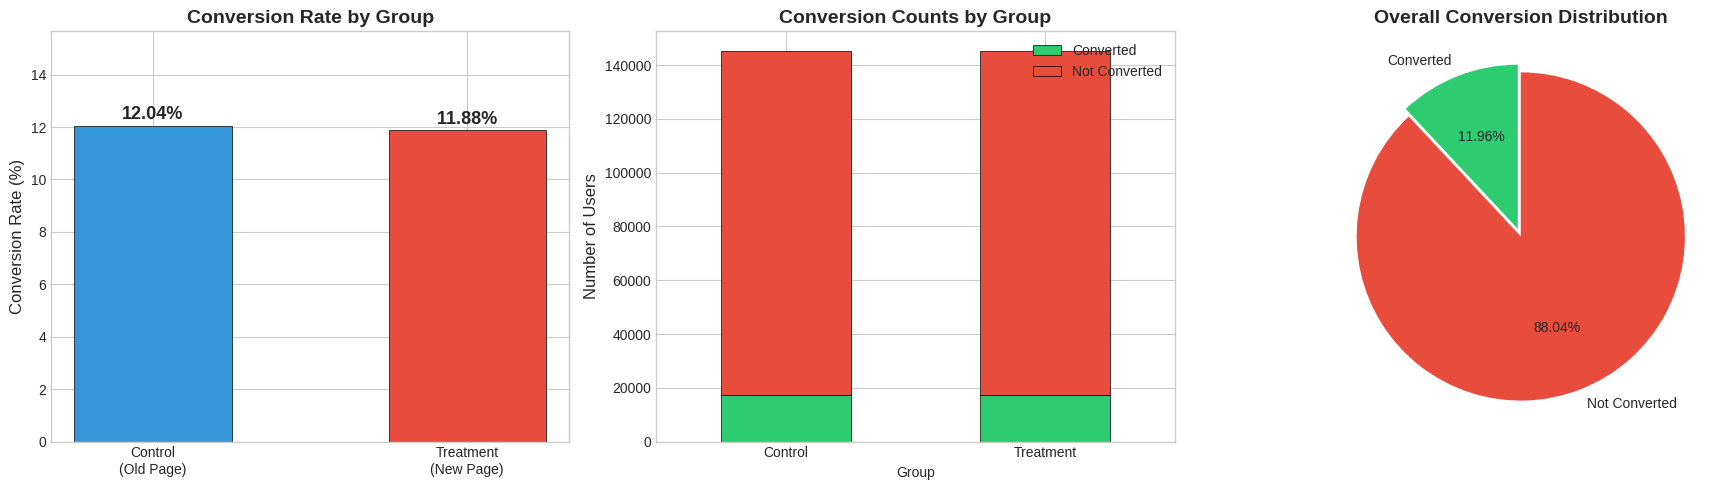

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates = [control_rate * 100, treatment_rate * 100]
colors = ['#3498db', '#e74c3c']
bars = axes[0].bar(groups, rates, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].set_title('Conversion Rate by Group', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max(rates) * 1.3)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'{rate:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Stacked bar
conv_data = pd.DataFrame({
    'Group': ['Control', 'Control', 'Treatment', 'Treatment'],
    'Status': ['Not Converted', 'Converted', 'Not Converted', 'Converted'],
    'Count': [len(control) - control['converted'].sum(), control['converted'].sum(),
              len(treatment) - treatment['converted'].sum(), treatment['converted'].sum()]
})
pivot = conv_data.pivot(index='Group', columns='Status', values='Count')
pivot[['Converted', 'Not Converted']].plot(kind='bar', stacked=True, ax=axes[1],
                                            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Conversion Counts by Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Users', fontsize=12)
axes[1].set_xticklabels(['Control', 'Treatment'], rotation=0)
axes[1].legend(fontsize=10)

# Pie chart
axes[2].pie([df_clean['converted'].sum(), len(df_clean) - df_clean['converted'].sum()],
            labels=['Converted', 'Not Converted'], autopct='%1.2f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0.05, 0))
axes[2].set_title('Overall Conversion Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Power Analysis & Sample Size Calculation
Before running the test, we calculate the minimum sample size needed to detect a meaningful difference with:
- **Significance Level (α):** 0.05
- **Statistical Power (1-β):** 0.80
- **Minimum Detectable Effect:** 1% lift in conversion rate

In [ ]:
baseline_rate = control_rate
min_detectable_effect = 0.01

effect_size = sm.stats.proportion_effectsize(baseline_rate, baseline_rate + min_detectable_effect)

power_analysis = NormalIndPower()
required_n = power_analysis.solve_power(
    effect_size=effect_size, alpha=0.05, power=0.80, alternative='two-sided'
)

print('=' * 50)
print('POWER ANALYSIS')
print('=' * 50)
print(f'\nBaseline Conversion Rate: {baseline_rate:.4f}')
print(f'Minimum Detectable Effect: {min_detectable_effect:.2%} absolute lift')
print(f'Effect Size (Cohens h): {effect_size:.4f}')
print('Significance Level (alpha): 0.05')
print('Statistical Power (1-beta): 0.80')
req = int(np.ceil(required_n))
print(f'\nRequired Sample Size per Group: {req:,}')
print(f'Total Required Sample Size: {req * 2:,}')
print(f'\nActual Control Group Size: {len(control):,}')
print(f'Actual Treatment Group Size: {len(treatment):,}')

if len(control) >= required_n and len(treatment) >= required_n:
    print('\nBoth groups exceed the required sample size. We have sufficient power.')
else:
    print('\nSample size may be insufficient for detecting a 1% lift.')

POWER ANALYSIS

Baseline Conversion Rate: 0.1204
Minimum Detectable Effect: 1.00% absolute lift
Effect Size (Cohens h): -0.0302
Significance Level (alpha): 0.05
Statistical Power (1-beta): 0.80

Required Sample Size per Group: 17,209
Total Required Sample Size: 34,418

Actual Control Group Size: 145,274
Actual Treatment Group Size: 145,310

Both groups exceed the required sample size. We have sufficient power.


## 4. Hypothesis Testing

**Hypotheses:**
- **H₀ (Null):** p_treatment = p_control (No difference in conversion rates)
- **H₁ (Alternative):** p_treatment ≠ p_control (There IS a difference)

**Method:** Two-proportion Z-test at α = 0.05

In [ ]:
n_control = len(control)
n_treatment = len(treatment)
successes = np.array([treatment['converted'].sum(), control['converted'].sum()])
nobs = np.array([n_treatment, n_control])

z_stat, p_value = proportions_ztest(successes, nobs, alternative='two-sided')

ci_control = proportion_confint(control['converted'].sum(), n_control, alpha=0.05, method='normal')
ci_treatment = proportion_confint(treatment['converted'].sum(), n_treatment, alpha=0.05, method='normal')

se_diff = np.sqrt(control_rate*(1-control_rate)/n_control + treatment_rate*(1-treatment_rate)/n_treatment)
ci_diff = (diff - 1.96 * se_diff, diff + 1.96 * se_diff)

print('=' * 50)
print('HYPOTHESIS TEST RESULTS')
print('=' * 50)
print(f'\nZ-Statistic: {z_stat:.4f}')
print(f'P-Value: {p_value:.4f}')
print('\nSignificance Level (alpha): 0.05')

if p_value < 0.05:
    print(f'\nRESULT: REJECT the null hypothesis (p = {p_value:.4f} < 0.05)')
    print('There IS a statistically significant difference between the groups.')
else:
    print(f'\nRESULT: FAIL TO REJECT the null hypothesis (p = {p_value:.4f} > 0.05)')
    print('There is NO statistically significant difference between the groups.')

print('\n95% Confidence Intervals:')
print(f'  Control:    ({ci_control[0]:.4f}, {ci_control[1]:.4f})')
print(f'  Treatment:  ({ci_treatment[0]:.4f}, {ci_treatment[1]:.4f})')
print(f'  Difference: ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})')

if ci_diff[0] <= 0 <= ci_diff[1]:
    print('\n  The confidence interval for the difference includes 0,')
    print('  confirming no significant difference.')

HYPOTHESIS TEST RESULTS

Z-Statistic: -1.3109
P-Value: 0.1899

Significance Level (alpha): 0.05

RESULT: FAIL TO REJECT the null hypothesis (p = 0.1899 > 0.05)
There is NO statistically significant difference between the groups.

95% Confidence Intervals:
  Control:    (0.1187, 0.1221)
  Treatment:  (0.1171, 0.1205)
  Difference: (-0.0039, 0.0008)

  The confidence interval for the difference includes 0,
  confirming no significant difference.


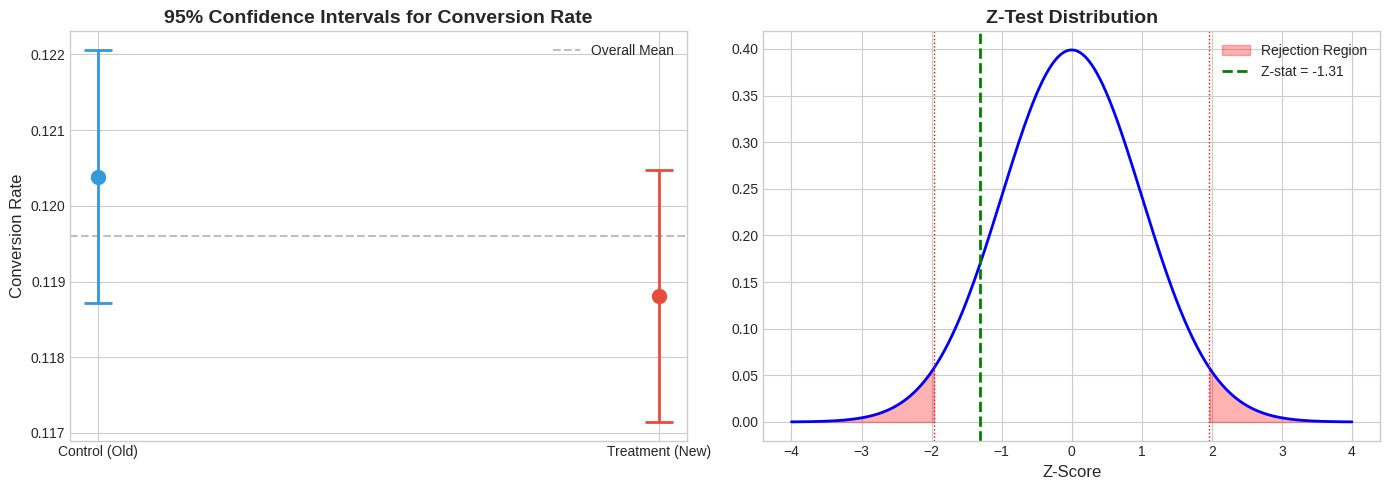

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence Intervals - plot each group separately
groups_ci = ['Control (Old)', 'Treatment (New)']
means = [control_rate, treatment_rate]
ci_lower = [ci_control[0], ci_treatment[0]]
ci_upper = [ci_control[1], ci_treatment[1]]
colors = ['#3498db', '#e74c3c']

for i, (grp, m, lo, hi, c) in enumerate(zip(groups_ci, means, ci_lower, ci_upper, colors)):
    axes[0].errorbar(grp, m, yerr=[[m - lo], [hi - m]], fmt='o', capsize=10, capthick=2,
                    markersize=10, color=c, elinewidth=2)
axes[0].set_ylabel('Conversion Rate', fontsize=12)
axes[0].set_title('95% Confidence Intervals for Conversion Rate', fontsize=14, fontweight='bold')
axes[0].axhline(y=df_clean['converted'].mean(), color='gray', linestyle='--', alpha=0.5, label='Overall Mean')
axes[0].legend()

# Z-distribution
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)
axes[1].plot(x, y, 'b-', linewidth=2)
axes[1].fill_between(x, y, where=(x <= -1.96), color='red', alpha=0.3, label='Rejection Region')
axes[1].fill_between(x, y, where=(x >= 1.96), color='red', alpha=0.3)
axes[1].axvline(x=z_stat, color='green', linestyle='--', linewidth=2, label=f'Z-stat = {z_stat:.2f}')
axes[1].axvline(x=-1.96, color='red', linestyle=':', linewidth=1)
axes[1].axvline(x=1.96, color='red', linestyle=':', linewidth=1)
axes[1].set_title('Z-Test Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Z-Score', fontsize=12)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

## 5. Country-Level Segmentation Analysis
Does the effect of the new page vary across different countries (US, UK, Canada)?

In [ ]:
df_merged = df_clean.merge(countries, on='id', how='inner')
print(f'Merged dataset: {len(df_merged):,} rows')
print('\nCountry Distribution:')
print(df_merged['country'].value_counts())

country_stats = df_merged.groupby(['country', 'con_treat']).agg(
    users=('id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean')
).round(4)
print('\nConversion Rates by Country & Group:')
print(country_stats)

print('\n' + '=' * 50)
print('Z-TEST BY COUNTRY')
print('=' * 50)
for country in df_merged['country'].unique():
    country_data = df_merged[df_merged['country'] == country]
    ctrl = country_data[country_data['con_treat'] == 'control']
    treat = country_data[country_data['con_treat'] == 'treatment']
    successes_c = np.array([treat['converted'].sum(), ctrl['converted'].sum()])
    nobs_c = np.array([len(treat), len(ctrl)])
    z_c, p_c = proportions_ztest(successes_c, nobs_c, alternative='two-sided')
    ctrl_r = ctrl['converted'].mean()
    treat_r = treat['converted'].mean()
    sig = 'Significant' if p_c < 0.05 else 'Not Significant'
    print(f'\n{country}:')
    print(f'  Control Rate: {ctrl_r:.4f}  |  Treatment Rate: {treat_r:.4f}')
    print(f'  Z-stat: {z_c:.4f}  |  P-value: {p_c:.4f}  |  {sig}')

Merged dataset: 290,584 rows

Country Distribution:
country
US    203619
UK     72466
CA     14499
Name: count, dtype: int64

Conversion Rates by Country & Group:
                    users  conversions  conversion_rate
country con_treat                                      
CA      control      7198          855           0.1188
        treatment    7301          817           0.1119
UK      control     36360         4364           0.1200
        treatment   36106         4375           0.1212
US      control    101716        12270           0.1206
        treatment  101903        12072           0.1185

Z-TEST BY COUNTRY

US:
  Control Rate: 0.1206  |  Treatment Rate: 0.1185
  Z-stat: -1.5052  |  P-value: 0.1323  |  Not Significant

CA:
  Control Rate: 0.1188  |  Treatment Rate: 0.1119
  Z-stat: -1.2969  |  P-value: 0.1947  |  Not Significant

UK:
  Control Rate: 0.1200  |  Treatment Rate: 0.1212
  Z-stat: 0.4749  |  P-value: 0.6349  |  Not Significant


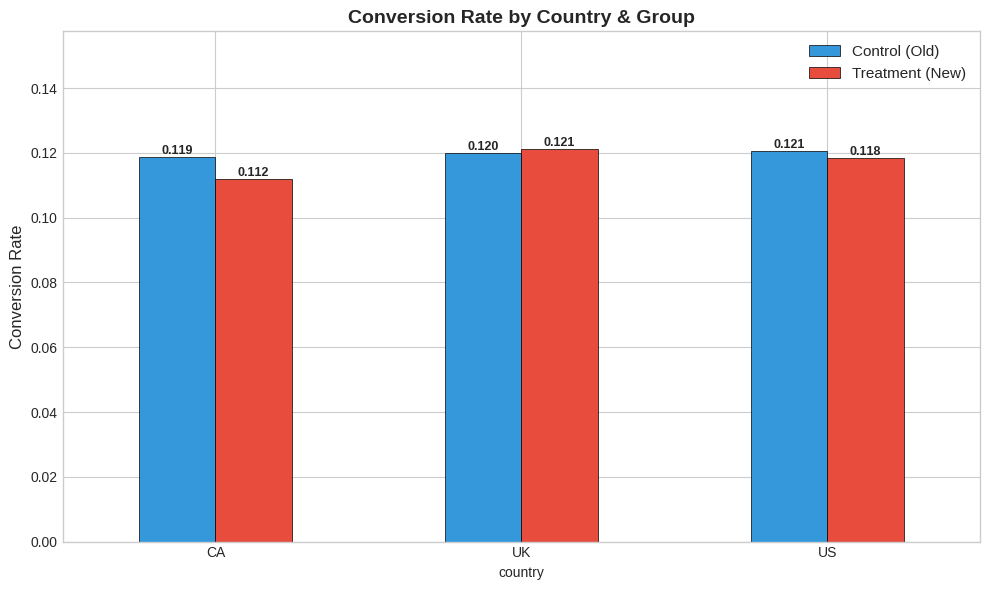

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
country_pivot = df_merged.groupby(['country', 'con_treat'])['converted'].mean().unstack()
country_pivot.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=0.5)
ax.set_ylabel('Conversion Rate', fontsize=12)
ax.set_title('Conversion Rate by Country & Group', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Control (Old)', 'Treatment (New)'], fontsize=11)
ax.set_ylim(0, country_pivot.max().max() * 1.3)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Logistic Regression
We use logistic regression to model the probability of conversion based on the treatment group and country, controlling for multiple variables simultaneously.

In [ ]:
df_model = df_merged.copy()
df_model['treatment'] = (df_model['con_treat'] == 'treatment').astype(int)
df_model = pd.get_dummies(df_model, columns=['country'], drop_first=True, dtype=int)

X = df_model[['treatment', 'country_UK', 'country_US']]
X = sm.add_constant(X)
y = df_model['converted']

logit_model = sm.Logit(y, X).fit(disp=0)
print(logit_model.summary2())

print('\n' + '=' * 50)
print('LOGISTIC REGRESSION INTERPRETATION')
print('=' * 50)
t_coef = logit_model.params['treatment']
t_pval = logit_model.pvalues['treatment']
t_odds = np.exp(t_coef)
print(f'\nTreatment Coefficient: {t_coef:.4f}')
print(f'Treatment P-value: {t_pval:.4f}')
print(f'Treatment Odds Ratio: {t_odds:.4f}')

if t_pval > 0.05:
    print('\nThe treatment (new page) is NOT a significant predictor of conversion.')
    print('This confirms our Z-test findings.')
else:
    print('\nThe treatment (new page) IS a significant predictor of conversion.')

                          Results: Logit
Model:              Logit            Method:           MLE        
Dependent Variable: converted        Pseudo R-squared: 0.000      
Date:               2026-02-15 04:32 AIC:              212781.1253
No. Observations:   290584           BIC:              212823.4439
Df Model:           3                Log-Likelihood:   -1.0639e+05
Df Residuals:       290580           LL-Null:          -1.0639e+05
Converged:          1.0000           LLR p-value:      0.17599    
No. Iterations:     6.0000           Scale:            1.0000     
-------------------------------------------------------------------
               Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
-------------------------------------------------------------------
const         -2.0300    0.0266  -76.2488  0.0000  -2.0822  -1.9778
treatment     -0.0149    0.0114   -1.3069  0.1912  -0.0374   0.0075
country_UK     0.0506    0.0284    1.7835  0.0745  -0.0050   0.1063
country_US     

## 7. Results Summary & Business Recommendation

In [ ]:
print('=' * 60)
print('  FINAL RESULTS SUMMARY')
print('=' * 60)
print()
print(f'  Control Conversion Rate:     {control_rate:.4f} ({control_rate*100:.2f}%)')
print(f'  Treatment Conversion Rate:   {treatment_rate:.4f} ({treatment_rate*100:.2f}%)')
print(f'  Absolute Difference:         {diff:.4f} ({diff*100:.4f}%)')
lift = (diff/control_rate)*100
print(f'  Relative Lift:               {lift:.2f}%')
print(f'  Z-Statistic:                 {z_stat:.4f}')
print(f'  P-Value:                     {p_value:.4f}')
print(f'  95% CI for Difference:       ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})')
t_pval = logit_model.pvalues['treatment']
print(f'  Logistic Reg P-value:        {t_pval:.4f}')
sig_text = 'Yes' if p_value < 0.05 else 'No'
print(f'  Statistical Significance:    {sig_text}')

print()
print('BUSINESS RECOMMENDATION:')
print('-' * 60)
if p_value >= 0.05:
    print()
    print('Based on the A/B test analysis of ~290K user sessions:')
    print()
    print('1. DECISION: DO NOT LAUNCH the new page.')
    print(f'   The new page shows no statistically significant improvement')
    print(f'   in conversion rate over the old page (p = {p_value:.4f}).')
    print()
    print('2. The confidence interval for the difference includes zero,')
    print('   meaning the observed difference could be due to random chance.')
    print()
    print('3. Country-level analysis shows consistent results across')
    print('   US, UK, and Canada - no subgroup shows a significant effect.')
    print()
    print('4. Logistic regression confirms that the treatment variable')
    print('   is not a significant predictor of conversion.')
    print()
    print('NEXT STEPS:')
    print('- Investigate qualitative user feedback on the new page design')
    print('- Consider testing more radical design changes (CTA, layout, pricing)')
    print('- Run follow-up tests targeting specific user segments')
    print('- Explore time-based effects with longer test duration')
else:
    print(f'The new page shows a statistically significant difference (p = {p_value:.4f}).')
    print('Recommend further analysis before full rollout.')

print()
print('=' * 60)
print('Analysis Complete.')
print('=' * 60)

  FINAL RESULTS SUMMARY

  Control Conversion Rate:     0.1204 (12.04%)
  Treatment Conversion Rate:   0.1188 (11.88%)
  Absolute Difference:         -0.0016 (-0.1578%)
  Relative Lift:               -1.31%
  Z-Statistic:                 -1.3109
  P-Value:                     0.1899
  95% CI for Difference:       (-0.0039, 0.0008)
  Logistic Reg P-value:        0.1912
  Statistical Significance:    No

BUSINESS RECOMMENDATION:
------------------------------------------------------------

Based on the A/B test analysis of ~290K user sessions:

1. DECISION: DO NOT LAUNCH the new page.
   The new page shows no statistically significant improvement
   in conversion rate over the old page (p = 0.1899).

2. The confidence interval for the difference includes zero,
   meaning the observed difference could be due to random chance.

3. Country-level analysis shows consistent results across
   US, UK, and Canada - no subgroup shows a significant effect.

4. Logistic regression confirms that the 